In this script we will make a quality control of the scRNA data.


In [1]:
import scanpy as scp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid.inset_locator import inset_axes

from parameters import *

import warnings

warnings.filterwarnings("ignore")

<ipython-input-1-a2a62b9ca704>:5: MatplotlibDeprecationWarning: 
The mpl_toolkits.axes_grid module was deprecated in Matplotlib 2.1 and will be removed two minor releases later. Use mpl_toolkits.axes_grid1 and mpl_toolkits.axisartist, which provide the same functionality instead.
  from mpl_toolkits.axes_grid.inset_locator import inset_axes


In [2]:
adata = scp.read("results/Raw.h5ad")

# QC measures <a name="QC"></a>

For each well, we compute the following QC measures:

 1. #UMIs counted per well
 2. #Genes counter per well
 3. Fraction of mitrochondrial gene counts

In [3]:
adata.obs["counts"] = adata.X.sum(axis=1)
adata.obs["genes"] = (adata.X > 0).sum(axis=1)
mtgenes = ["mt-" in i for i in adata.var["gene_name"]]
adata.obs["mtFraction"] = (adata[:,mtgenes].X).sum(axis=1)
adata.obs["mtFraction"] /= adata.obs["counts"].values

## Bulk statistics <a name="Bulk"></a>

First we check the statistics in terms of the bulk data and set hard thresholds for sectioning the data.

From the gene histogram and the scatter plot, the data show a bimodality in the number of number of genes expressed. Appart from this bimodality there does not appear to be outliers with high counts that could indicate the presence of clear doublets, which is consistent with the fact that the methods in general has low rates of doublets. 

In [4]:
COUNTS_MIN = 400000
GENES_MIN = 1000
MTFRACTION_MAX = 0.2

print("Threshold  minimum UMI counts: ", COUNTS_MIN)
print("Threshold  minimum Gene counts: ", GENES_MIN)
print("Threshold  maximum mtfraction counts: ", MTFRACTION_MAX)

Threshold  minimum UMI counts:  400000
Threshold  minimum Gene counts:  1000
Threshold  maximum mtfraction counts:  0.2


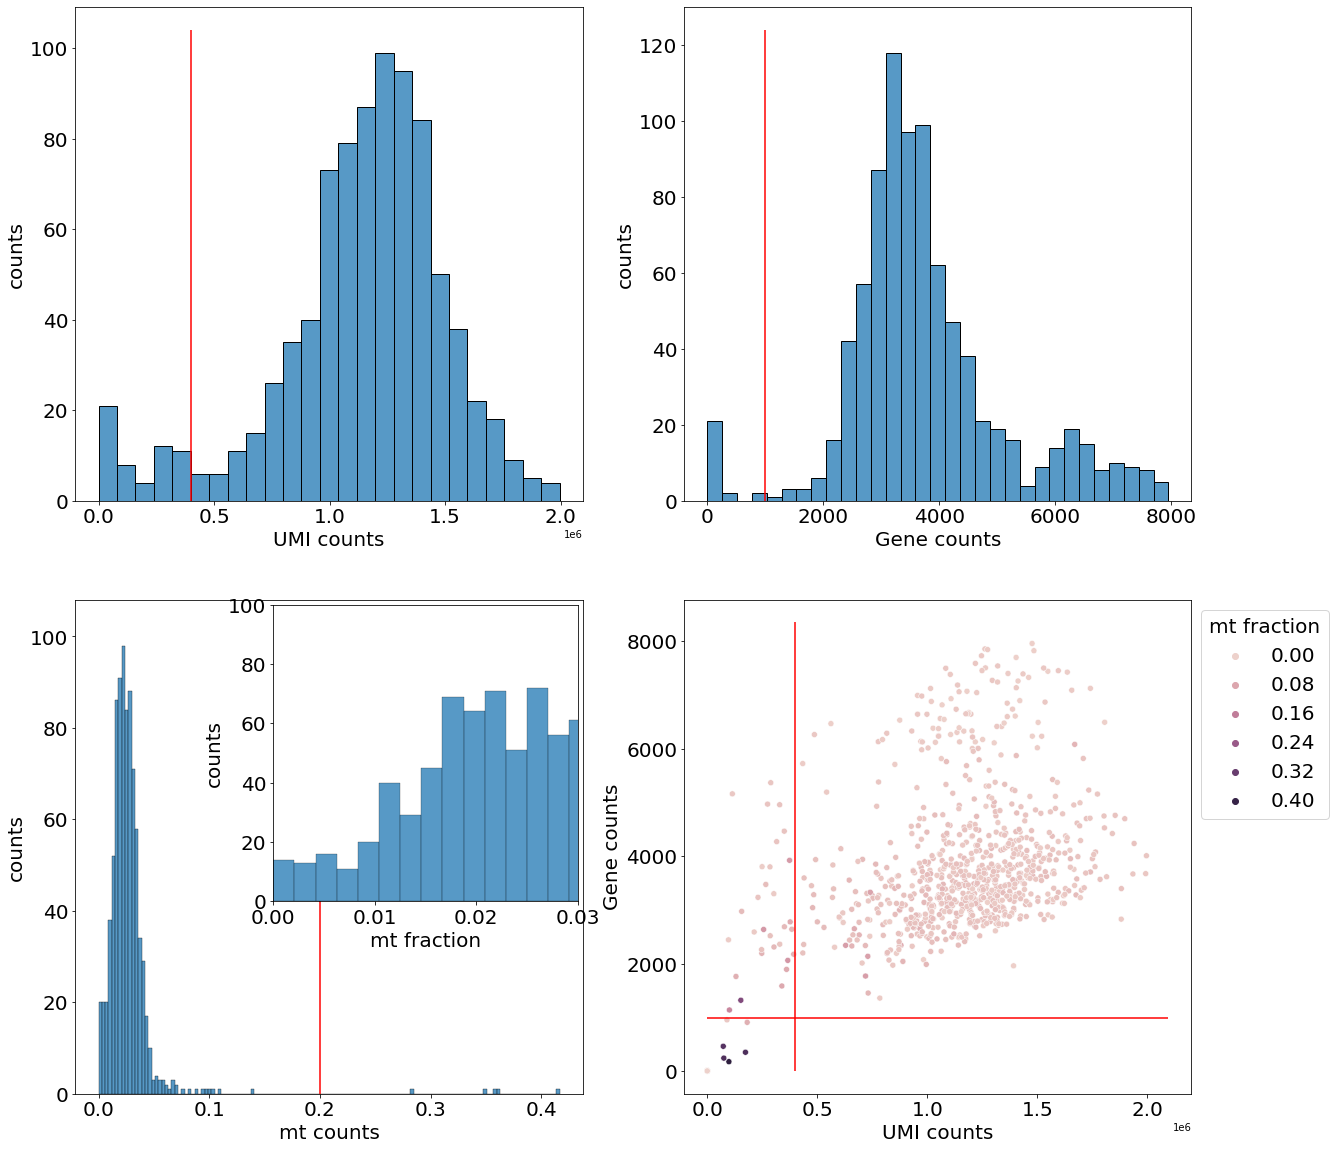

In [5]:
fig,ax = plt.subplots(2,2,figsize=[20,20])

sns.histplot(data=adata.obs,x="counts",ax=ax[0,0])
ax[0,0].set_xlabel("UMI counts",fontsize=20)
ax[0,0].set_ylabel("counts",fontsize=20)
ax[0,0].tick_params(labelsize=20)
ax[0,0].vlines(COUNTS_MIN,0,ax[0,0].get_ybound()[1],color="r")

sns.histplot(data=adata.obs,x="genes",ax=ax[0,1])
ax[0,1].set_xlabel("Gene counts",fontsize=20)
ax[0,1].set_ylabel("counts",fontsize=20)
ax[0,1].tick_params(labelsize=20)
ax[0,1].vlines(GENES_MIN,0,ax[0,1].get_ybound()[1],color="r")

sns.histplot(data=adata.obs,x="mtFraction",ax=ax[1,0])
ax[1,0].set_xlabel("mt counts",fontsize=20)
ax[1,0].set_ylabel("counts",fontsize=20)
ax[1,0].tick_params(labelsize=20)
ax[1,0].vlines(MTFRACTION_MAX,0,ax[1,0].get_ybound()[1],color="r")
subax = inset_axes(ax[1,0],
                    width="60%",
                    height="60%",
                    loc="upper right")
sns.histplot(data=adata.obs,x="mtFraction",bins=200,ax=subax)
subax.axis([0,0.03,0,100])
subax.set_xlabel("mt fraction",fontsize=20)
subax.set_ylabel("counts",fontsize=20)
subax.tick_params(labelsize=20)

sns.scatterplot(data=adata.obs,y="genes",x="counts",hue="mtFraction",ax=ax[1,1])
ax[1,1].set_xlabel("UMI counts",fontsize=20)
ax[1,1].set_ylabel("Gene counts",fontsize=20)
ax[1,1].tick_params(labelsize=20)
ax[1,1].legend(title="mt fraction" ,bbox_to_anchor=(1,1), loc="upper left", fontsize=20, title_fontsize=20)
ax[1,1].hlines(GENES_MIN,0,ax[1,1].get_xbound()[1],color="r")
ax[1,1].vlines(COUNTS_MIN,0,ax[1,1].get_ybound()[1],color="r")

fig.savefig("plots/QC_global.png")
fig.show()

## By tag conditions <a name="Tag"></a>

We now check the statistics by conditions:

 1. Time events
 2. Biological condition
 3. Plate
 4. Sample
 
 Several observations can be made:
 
  1. The bimodality comes from cells at stage 120hr. These cells show systematically more genes expressed.
  2. "Black" tag that corresponded to doublet cells conditions have more genes expressed on average except than the P1 plate that are the cells at 120hr.
  3. "Empty" tagged droplets show consistently a lower number of genes and UMI expressed except for the presence of some outlier. This cells seem consistently empty.

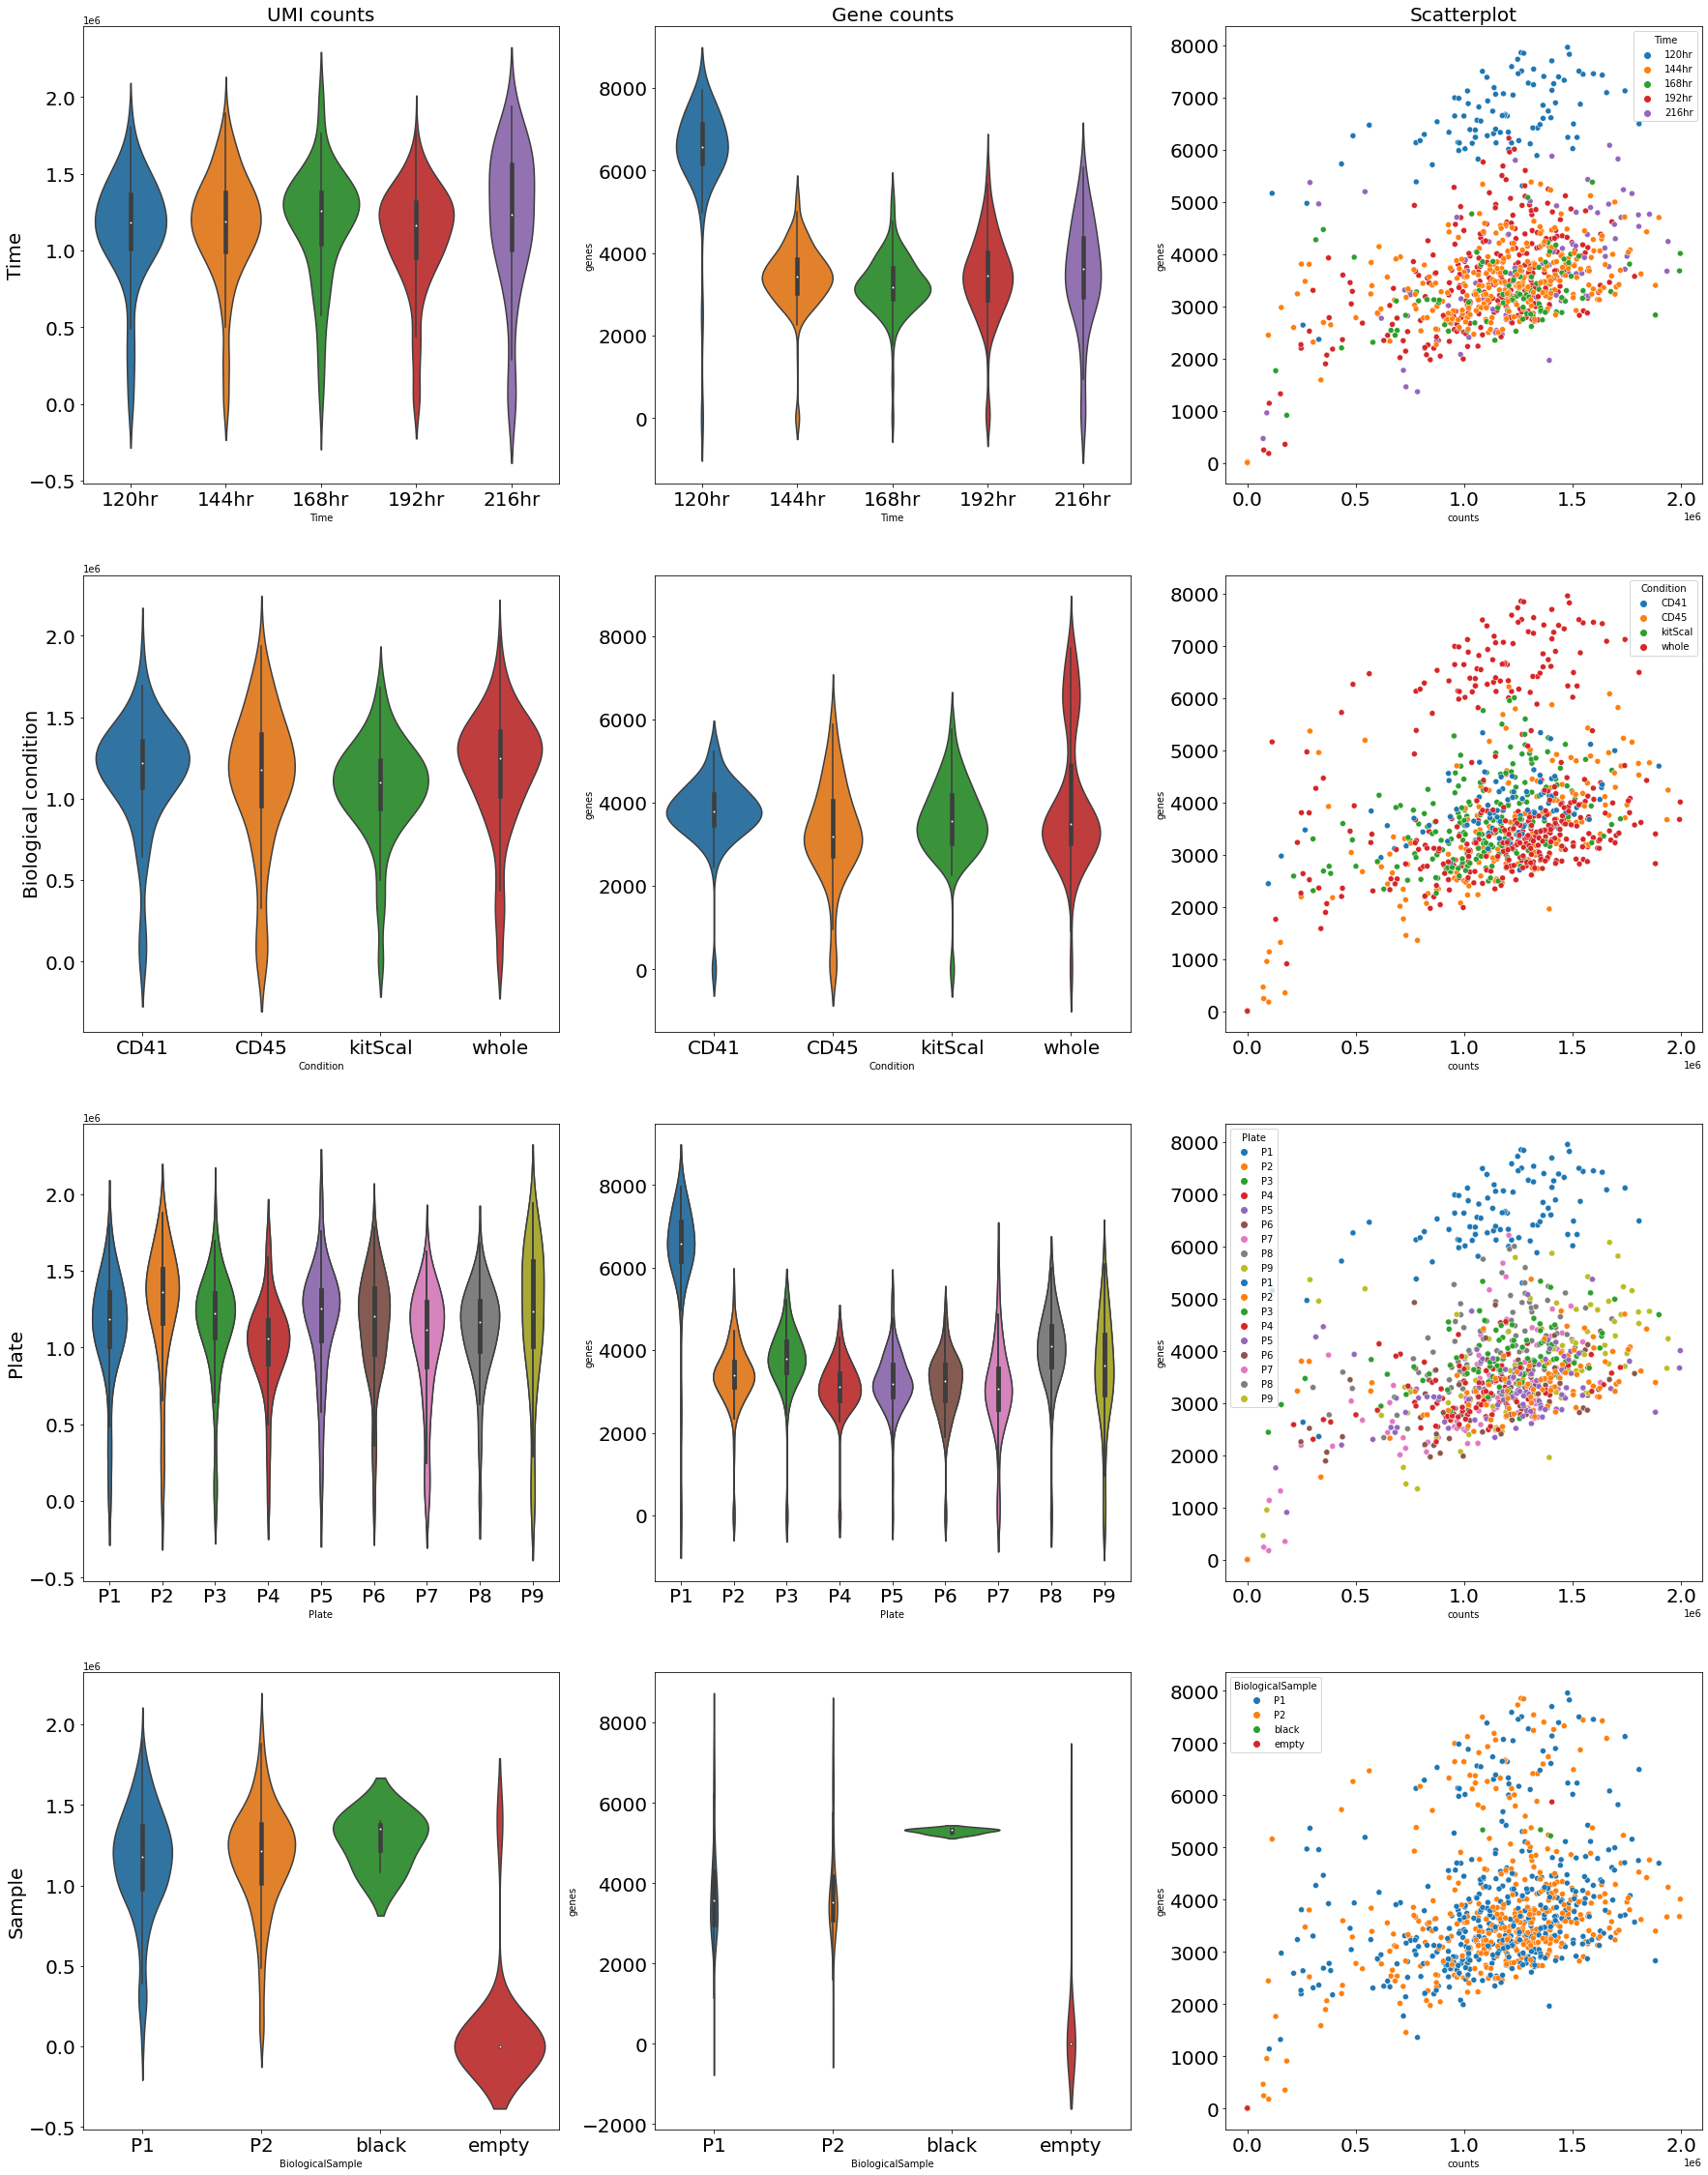

In [6]:
fig,ax = plt.subplots(4,3,figsize=[30,40])

#time
sns.violinplot(data=adata.obs,x="Time",y="counts",ax=ax[0,0])
ax[0,0].tick_params(labelsize=20)
sns.violinplot(data=adata.obs,x="Time",y="genes",ax=ax[0,1])
ax[0,1].tick_params(labelsize=20)
sns.scatterplot(data=adata.obs,x="counts",y="genes",hue="Time",ax=ax[0,2])
ax[0,2].tick_params(labelsize=20)

#biological condition
sns.violinplot(data=adata.obs,x="Condition",y="counts",ax=ax[1,0])
ax[1,0].tick_params(labelsize=20)
sns.violinplot(data=adata.obs,x="Condition",y="genes",ax=ax[1,1])
ax[1,1].tick_params(labelsize=20)
sns.scatterplot(data=adata.obs,x="counts",y="genes",hue="Condition",ax=ax[1,2])
ax[1,2].tick_params(labelsize=20)

#plate
sns.violinplot(data=adata.obs,x="Plate",y="counts",ax=ax[2,0])
ax[2,0].tick_params(labelsize=20)
sns.violinplot(data=adata.obs,x="Plate",y="genes",ax=ax[2,1])
ax[2,1].tick_params(labelsize=20)
sns.scatterplot(data=adata.obs,x="counts",y="genes",hue="Plate",ax=ax[2,2])
ax[2,2].tick_params(labelsize=20)

#plate
sns.violinplot(data=adata.obs,x="Plate",y="counts",ax=ax[2,0])
ax[2,0].tick_params(labelsize=20)
sns.violinplot(data=adata.obs,x="Plate",y="genes",ax=ax[2,1])
ax[2,1].tick_params(labelsize=20)
sns.scatterplot(data=adata.obs,x="counts",y="genes",hue="Plate",ax=ax[2,2])
ax[2,2].tick_params(labelsize=20)

#sample
sns.violinplot(data=adata.obs,x="BiologicalSample",y="counts",ax=ax[3,0])
ax[3,0].tick_params(labelsize=20)
sns.violinplot(data=adata.obs,x="BiologicalSample",y="genes",ax=ax[3,1])
ax[3,1].tick_params(labelsize=20)
sns.scatterplot(data=adata.obs,x="counts",y="genes",hue="BiologicalSample",ax=ax[3,2])
ax[3,2].tick_params(labelsize=20)

ax[0,0].set_title("UMI counts",fontsize=20)
ax[0,1].set_title("Gene counts",fontsize=20)
ax[0,2].set_title("Scatterplot",fontsize=20)
ax[0,0].set_ylabel("Time",fontsize=20)
ax[1,0].set_ylabel("Biological condition",fontsize=20)
ax[2,0].set_ylabel("Plate",fontsize=20)
ax[3,0].set_ylabel("Sample",fontsize=20)

fig.savefig("plots/QC_tags.png")
fig.show()

# Measures with error in the flow cytometer <a name="Measures"></a>

We can observe that the measures that do not have any flow cytommetry measure are cells that seem valid cells. We can further observe that there is one well declared as empty that has robably populated with a valid cell. This is consistent with the outlier tail in the sample violin plot. 

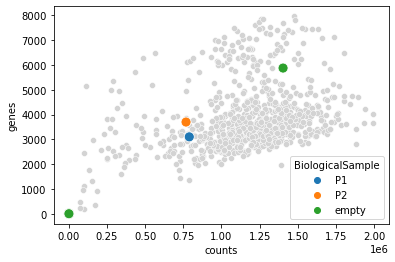

In [7]:
sns.scatterplot(data=adata[np.invert(adata.obs["FSC-A"].isna())].obs,x="counts",y="genes",color="lightgrey")
sns.scatterplot(data=adata[adata.obs["FSC-A"].isna()].obs,x="counts",y="genes",s=100,hue="BiologicalSample")

plt.savefig("plots/QC_no_flow_measure.png")

In [8]:
adata[adata.obs["FSC-A"].isna()].obs

,Cell,Plate,Time,Condition,BiologicalSample,Flow Cytommetry File,FSC-A,FSC-H,FSC-W,SSC-A,...,GFP FLK-1 530/30 Blue-A,582/15 Y/G-A,PE Dazzle 594 CD41 610/20 Y/G-A,PECy7 Sca-1 780/60 Y/G-A,APC CD45 660/20 Red-A,APCCy7 cKIT 780/60 Red-A,Hoechst 58 450/40 Violet-A,counts,genes,mtFraction
89,HG3JFDRXY_IDT-DUI-NXT-282,P1,120hr,whole,empty,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN
95,HG3JFDRXY_IDT-DUI-NXT-288,P1,120hr,whole,empty,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN
192,HG5V7DRXY_IDT-DUI-NXT-186,P7,192hr,CD45,empty,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.0,7,0.000000
199,HG5V7DRXY_IDT-DUI-NXT-192,P7,192hr,CD45,empty,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.0,16,0.000000
299,HG5V7DRXY_IDT-DUI-NXT-282,P8,192hr,kitScal,empty,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN
305,HG5V7DRXY_IDT-DUI-NXT-288,P8,192hr,kitScal,empty,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.0,7,0.000000
400,HG5V7DRXY_IDT-DUI-NXT-378,P9,216hr,CD45,empty,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1403989.0,5871,0.033170
407,HG5V7DRXY_IDT-DUI-NXT-384,P9,216hr,CD45,empty,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0,3,0.000000
465,HG5V7DRXY_IDT-DUI-NXT-90,P6,192hr,whole,empty,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,112.0,16,0.000000
471,HG5V7DRXY_IDT-DUI-NXT-96,P6,192hr,whole,empty,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.0,18,0.000000


# Filter cells and save <a name="Filter"></a>

From the quality control we will remove all cells with the following characteristics:

 1. Cells that not follow the hard threshold conditions
 2. Cells that were tagged as empty, even the one that could be a valid cell
 3. Cells that where tagged as black as being possible doublets
 
A further note, since the experimental method has a very reduced amount of doublets. We assume that the rest of the wells correspond to true cells and we will not explore it further. Current methods for doublet removal will not be effective in such small samples

In [9]:
shape = adata.shape

scp.pp.filter_cells(adata,min_counts=200000)
scp.pp.filter_genes(adata,min_cells=1)
adata = adata[adata.obs["mtFraction"]<MTFRACTION_MAX,:]
adata = adata[adata.obs["BiologicalSample"]!="black",:]

print("Cells retained after cutoffs: ",adata.shape[0],"/",shape[0]," (",np.round(100*adata.shape[0]/shape[0],2),"%)")
print("Genes that are expressed at least in one cell: ",adata.shape[1],"/",shape[1]," (",np.round(100*adata.shape[1]/shape[1],2),"%)")

Cells retained after cutoffs:  824 / 858  ( 96.04 %)
Genes that are expressed at least in one cell:  29526 / 53700  ( 54.98 %)


In [10]:
adata.write("results/QC.h5ad")